In [1]:
# Deactivate distracting warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
from utils.data_processing import *
from utils.visualization import load_data, plot_event_count, plot_kde, plot_goal_positions
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

In [3]:
path = "./idsse-data/DFL-MAT-J03WOH/"
file_name_pos = "DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WOH.xml"
file_name_infos = "DFL_02_01_matchinformation_DFL-COM-000002_DFL-MAT-J03WOH.xml"
file_name_events = "DFL_03_02_events_raw_DFL-COM-000002_DFL-MAT-J03WOH.xml"
xy_objects, events, pitch, possession, ballstatus, teamsheets = load_data(path, file_name_pos, file_name_infos, file_name_events)

len(xy_objects["firstHalf"]["Home"][0])=40

In [4]:
def get_first_half_players(valid_counts, positions):
    """
    valid_counts: 각 컬럼별 정상 데이터 개수가 담긴 리스트나 배열 (예: 40개 요소)
    positions: 선수 인덱스를 인덱스로 갖는 포지션 Series (예: 20개 요소)
    """
    starting_players = {}
    
    # 총 선수 명수 계산 (컬럼 수 / 2)
    num_players = len(valid_counts) // 2
    
    for i in range(num_players):
        # 선수의 x좌표 컬럼 인덱스 계산 (0, 2, 4, 6...)
        # y좌표는 2*i + 1이지만, x좌표 하나만 검사해도 출전 여부 파악 가능
        x_col_idx = i * 2 
        
        # 해당 선수의 좌표 데이터가 1개라도 존재한다면(0보다 크다면) 출전한 선수로 간주
        if valid_counts[x_col_idx] > 0:
            # 포지션 Series에서 해당 인덱스(i)의 포지션 값을 가져옴
            pos = positions[i]
            
            # 딕셔너리에 추가
            starting_players[i] = pos
            
    return starting_players

In [5]:
teamsheets['Home']['position']

0      STZ
1     None
2      STZ
3       RV
4      IVR
5      ORM
6      DML
7      DMR
8      IVL
9       ZO
10      ZO
11      TW
12      LV
13     OLM
14    None
15     OLM
16     IVR
17    None
18    None
19     ORM
Name: position, dtype: object

In [6]:
Home_first = xy_objects["firstHalf"]["Home"].xy 
Away_first = xy_objects["firstHalf"]["Away"].xy 
non_nan_counts = np.sum(~np.isnan(Home_first), axis=0)
non_nan_counts_2 = np.sum(~np.isnan(Away_first), axis=0)
print("각 컬럼별 정상(non-NaN) 데이터 개수:")
print(non_nan_counts)
print(non_nan_counts_2)

각 컬럼별 정상(non-NaN) 데이터 개수:
[    0     0     0     0 69424 69424 69424 69424 69424 69424 69424 69424
 69424 69424 69424 69424 69424 69424 69424 69424     0     0 69424 69424
 69424 69424     0     0     0     0 69424 69424     0     0     0     0
     0     0     0     0]
[69424 69424 69424 69424 69424 69424 69424 69424     0     0 69424 69424
 69424 69424     0     0 69424 69424     0     0     0     0 69424 69424
 69424 69424 69424 69424     0     0     0     0 69424 69424     0     0
     0     0]


In [7]:
result_Home = get_first_half_players(non_nan_counts, teamsheets['Home']['position'])
result_Away = get_first_half_players(non_nan_counts_2, teamsheets['Away']['position'])

print("Home 전반전 출전 선수 (인덱스: 포지션):")
for idx, pos in result_Home.items():
    print(f"Index {idx:2d} : {pos}")
print("Away 전반전 출전 선수 (인덱스: 포지션):")
for idx, pos in result_Away.items():
    print(f"Index {idx:2d} : {pos}")

Home 전반전 출전 선수 (인덱스: 포지션):
Index  2 : STZ
Index  3 : RV
Index  4 : IVR
Index  5 : ORM
Index  6 : DML
Index  7 : DMR
Index  8 : IVL
Index  9 : ZO
Index 11 : TW
Index 12 : LV
Index 15 : OLM
Away 전반전 출전 선수 (인덱스: 포지션):
Index  0 : LV
Index  1 : DMR
Index  2 : OLM
Index  3 : IVR
Index  5 : ORM
Index  6 : TW
Index  8 : DML
Index 11 : STZ
Index 12 : RV
Index 13 : ZO
Index 16 : IVL


In [8]:
Home_first_df = pd.DataFrame(Home_first)
Away_first_df = pd.DataFrame(Away_first)

In [9]:
def filter_defenders(result, target_positions = ['LV', 'IVL', 'IVR', 'RV']):
    target_columns = []
    new_column_names = []

    for player_idx, pos in result.items():
        if pos in target_positions:
            # x좌표 컬럼: 인덱스 * 2, y좌표 컬럼: 인덱스 * 2 + 1
            x_col = player_idx * 2
            y_col = player_idx * 2 + 1
            
            target_columns.extend([x_col, y_col])
            new_column_names.extend([f'{pos}_x', f'{pos}_y'])
    return target_columns, new_column_names

In [10]:
target_col_home, new_col_home = filter_defenders(result_Home)
target_col_away, new_col_away = filter_defenders(result_Away)

filtered_df_Home = Home_first_df[target_col_home]
filtered_df_Home.columns = new_col_home

filtered_df_Away = Away_first_df[target_col_away]
filtered_df_Away.columns = new_col_away

print(filtered_df_Home.head())
print(filtered_df_Away.head())

    RV_x   RV_y  IVR_x  IVR_y  IVL_x  IVL_y   LV_x   LV_y
0  12.53  20.32  16.45   6.50  17.32  -5.08  13.81 -14.50
1  12.55  20.34  16.47   6.56  17.29  -5.07  13.82 -14.52
2  12.59  20.35  16.51   6.60  17.27  -5.06  13.84 -14.54
3  12.62  20.38  16.54   6.65  17.25  -5.05  13.85 -14.56
4  12.65  20.41  16.57   6.70  17.22  -5.04  13.87 -14.57
    LV_x   LV_y  IVR_x  IVR_y   RV_x   RV_y  IVL_x  IVL_y
0 -10.31  21.76 -21.51   1.08 -15.58 -14.87 -20.06  11.81
1 -10.27  21.77 -21.49   1.06 -15.57 -14.90 -20.08  11.84
2 -10.22  21.78 -21.47   1.04 -15.56 -14.93 -20.09  11.86
3 -10.19  21.79 -21.45   1.01 -15.55 -14.96 -20.11  11.88
4 -10.13  21.80 -21.42   0.99 -15.54 -15.00 -20.14  11.91


so candiate threshold is 4.5, 4.6, 4.7

In [11]:
thr = 5.8

In [29]:
def classify_morphology(row, x_columns):
    x_values = row[x_columns]
    x_min = x_values.max()
    x_max = x_values.min()
    x_range = abs(x_max - x_min)
    
    if x_range <= 5.8:
        return 'line'
    
    # 3등분
    delta = x_range / 3
    x_low_max = x_min - delta
    x_high_min = x_max + delta
    
    # 각 선수의 영역 분류
    zones = {}
    for col in x_columns:
        x = row[col]
        if x >= x_low_max:
            zones[col] = 'low'
        elif x <= x_high_min:
            zones[col] = 'high'
        else:
            zones[col] = 'middle'
    
    # 영역별 카운트
    zone_counts = {'high': 0, 'middle': 0, 'low': 0}
    for zone in zones.values():
        zone_counts[zone] += 1
    
    # === 패턴 분류 ===
    
    # 1. 3명 low, 1명 high
    if zone_counts['low'] == 3 and zone_counts['high'] == 1:
        if zones['RV_x'] == 'high':
            return 'right_wing_push'
        if zones['IVR_x'] == 'high':
            return 'right_cb_push'
        if zones['IVL_x'] == 'high':
            return 'left_cb_push'
        if zones['LV_x'] == 'high':
            return 'left_wing_push'
    
    # 2. 3명 high, 1명 low
    if zone_counts['high'] == 3 and zone_counts['low'] == 1:
        if zones['RV_x'] == 'low':
            return 'right_wing_drop'
        if zones['IVR_x'] == 'low':
            return 'right_cb_drop'
        if zones['IVL_x'] == 'low':
            return 'left_cb_drop'
        if zones['LV_x'] == 'low':
            return 'left_wing_drop'
    
    # 3. 2명 high, 2명 low (middle 없음)
    if zone_counts['high'] == 2 and zone_counts['low'] == 2 and zone_counts['middle'] == 0:
        # 양 풀백 vs 센터백
        if zones['RV_x'] == 'high' and zones['LV_x'] == 'high':
            return 'wings_push'
        if zones['IVR_x'] == 'high' and zones['IVL_x'] == 'high':
            return 'center_push'
        
        # 좌우 분리
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'high':
            return 'right_side_high'
        if zones['IVL_x'] == 'high' and zones['LV_x'] == 'high':
            return 'left_side_high'
        
        # 대각선
        # RV(RB) + IVL(LCB) 둘 다 high
        if zones['RV_x'] == 'high' and zones['IVL_x'] == 'high':
            return 'diagonal_rv_ivl'
        
        # LV(LB) + IVR(RCB) 둘 다 high  ← 이미지의 경우!
        if zones['LV_x'] == 'high' and zones['IVR_x'] == 'high':
            return 'diagonal_lv_ivr'
    
    # 4. Middle - One Up & Two Down -12
    if zone_counts['middle'] == 1:
        if zones['IVL_x'] == 'low' and zones['IVR_x'] == 'low':
            if zones['LV_x'] == 'middle' and zones['RV_x'] == 'high':
                return '1002'
            elif zones['LV_x'] == 'high' and zones['RV_x'] == 'middle':
                return '2001'
        if zones['LV_x'] == 'middle' and zones['IVL_x'] == 'low' and zones['IVR_x'] == 'high' and zones['RV_x'] == 'low':
            return '1020'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'low':
            return '0201'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'high':
            return '2100'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'low':
            return '0012'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'low':
            return '0120'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'low':
            return '0210'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'low':
            return '0021'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'middle':
            return '1200'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'high':
            return '2010'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'low':
            return '0102'
    #5.Two Up & One Down - 12    
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'low':
            return '0221'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'high':
            return '2021'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'low':
            return '0122'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'high':
            return '2102'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'high':
            return '2201'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'low':
            return '0212'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'high':
            return '2120'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'middle':
            return '1022'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'high':
            return '2012'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'high':
            return '2210'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'middle':
            return '1202'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'middle':
            return '1220'
    if zone_counts['middle'] == 2:
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'low':
            return '0112'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'middle':
            return '1012'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'low':
            return '0211'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'middle':
            return '1201'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'middle':
            return '1102'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'low':
            return '0121'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'middle':
            return '1210'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'high':
            return '2011'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'middle':
            return '1021'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'middle':
            return '1120'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'high':
            return '2101'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'high':
            return '2110'
    
    # 6. 기타
    return 'mixed_formation'
 
        

# 적용
x_columns = ['RV_x', 'IVR_x', 'IVL_x', 'LV_x']
filtered_df_Home['morphology'] = filtered_df_Home.apply(
    lambda row: classify_morphology(row, x_columns), axis=1
)

print(filtered_df_Home[['RV_x', 'IVR_x', 'IVL_x', 'LV_x', 'morphology']].head(10))

    RV_x  IVR_x  IVL_x   LV_x morphology
0  12.53  16.45  17.32  13.81       line
1  12.55  16.47  17.29  13.82       line
2  12.59  16.51  17.27  13.84       line
3  12.62  16.54  17.25  13.85       line
4  12.65  16.57  17.22  13.87       line
5  12.70  16.61  17.19  13.89       line
6  12.74  16.65  17.16  13.91       line
7  12.79  16.69  17.14  13.93       line
8  12.83  16.74  17.12  13.95       line
9  12.88  16.78  17.08  13.97       line


morphology
line               18224
wings_push         14787
2001                7742
left_wing_push      5323
1002                3675
0221                3045
right_wing_push     2839
2012                2286
1012                1829
2102                1323
right_cb_drop        828
2101                 782
2011                 705
2021                 497
right_cb_push        448
0102                 407
0012                 377
diagonal_lv_ivr      315
1022                 313
left_side_high       279
0201                 277
1102                 267
diagonal_rv_ivl      265
2010                 257
2201                 249
left_cb_push         249
center_push          197
right_wing_drop      190
0112                 188
2100                 181
0211                 170
0120                 144
0212                 143
1021                 106
2110                  88
2120                  79
1202                  68
0122                  66
left_cb_drop          62
1200          

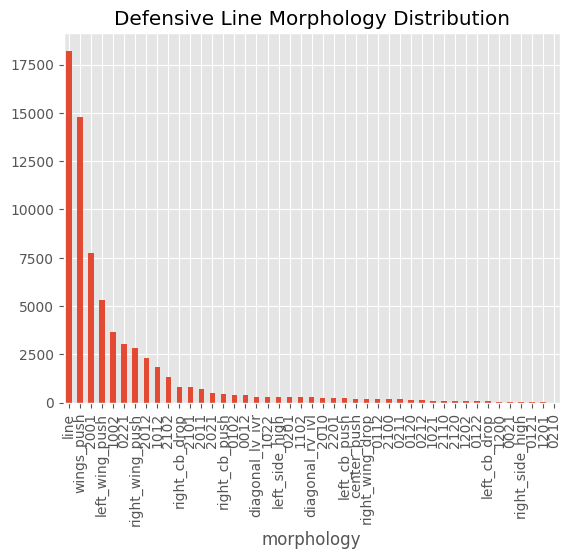

In [27]:
# 형태별 빈도 분석
morphology_counts = filtered_df_Home['morphology'].value_counts()
print(morphology_counts)

# 시간대별 형태 변화
import matplotlib.pyplot as plt
filtered_df_Home['morphology'].value_counts().plot(kind='bar')
plt.title('Defensive Line Morphology Distribution')
plt.show()

In [30]:
import matplotlib.pyplot as plt
import os

def visualize_morphology_samples(df, x_columns, output_dir='morphology_images'):
    """
    각 morphology 유형별로 1개씩 샘플 이미지 생성
    
    Parameters:
    - df: 데이터프레임 (morphology 컬럼 포함)
    - x_columns: ['RV_x', 'IVR_x', 'IVL_x', 'LV_x']
    - output_dir: 이미지 저장 디렉토리
    """
    
    # 출력 디렉토리 생성
    os.makedirs(output_dir, exist_ok=True)
    
    # Y 좌표 컬럼 (X와 매칭되도록)
    y_columns = [col.replace('_x', '_y') for col in x_columns]
    
    # 각 morphology 유형별로 첫 번째 샘플 추출
    morphology_types = df['morphology'].unique()
    
    print(f"총 {len(morphology_types)}개의 morphology 유형 발견")
    print(f"유형: {morphology_types}\n")
    
    for morph_type in morphology_types:
        # 해당 유형의 첫 번째 샘플 가져오기
        sample = df[df['morphology'] == morph_type].iloc[0]
        
        # 좌표 추출
        x_coords = sample[x_columns].values
        y_coords = sample[y_columns].values
    
        
        fig, ax = plt.subplots(figsize=(12, 8))
        pitch.plot(ax=ax)
        
        # 수비 라인 그리기
        ax.plot(x_coords, y_coords, color='red', linestyle='--', 
                linewidth=2.5, zorder=1, label='Defensive Line')
        
        # 선수 위치 표시
        ax.scatter(x_coords, y_coords, color='blue', s=150, 
                   edgecolors='white', linewidth=2, zorder=2)
        
        # 포지션 라벨
        positions = ['RB', 'RCB', 'LCB', 'LB']  # RV, IVR, IVL, LV 순서
        for i in range(4):
            ax.text(x_coords[i], y_coords[i] + 2, positions[i], 
                    color='black', fontsize=12, ha='center', va='center', 
                    fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.8, 
                             edgecolor='black', boxstyle='round,pad=0.3'))
        
        # X 범위 계산 및 표시
        x_range = x_coords.max() - x_coords.min()
        
        # 제목 설정
        title = f"Morphology: {morph_type}\n"
        title += f"X Range: {x_range:.2f}m | Frame: {sample.name}"
        ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
        
        # 범례 추가
        ax.legend(loc='upper right', fontsize=10)
        
        # 저장
        filename = f"{output_dir}/{morph_type}.png"
        plt.savefig(filename, dpi=150, bbox_inches='tight', 
                    facecolor='white', edgecolor='none')
        print(f"✅ 저장 완료: {filename}")
        
        plt.close()
    
    print(f"\n🎉 총 {len(morphology_types)}개 이미지 생성 완료!")
    print(f"📁 저장 위치: {output_dir}/")


# 사용 예시
x_columns = ['RV_x', 'IVR_x', 'IVL_x', 'LV_x']
visualize_morphology_samples(filtered_df_Home, x_columns, output_dir='morphology_images')

총 45개의 morphology 유형 발견
유형: ['line' '1002' 'wings_push' 'left_side_high' '2100' 'left_wing_push'
 '2010' '2110' '0210' '1210' '2001' '2012' '1102' '2102' '2101'
 'right_cb_drop' '2201' 'right_wing_push' 'right_cb_push' '0012' '0102'
 '1012' '1202' '2011' '1022' 'right_side_high' '0021' '0120' '1120' '1220'
 'right_wing_drop' '2210' 'diagonal_rv_ivl' '0201' 'left_cb_push' '1201'
 '0112' '1021' 'left_cb_drop' 'diagonal_lv_ivr' '2120' 'center_push'
 '1200' '0212' '2021']

✅ 저장 완료: morphology_images/line.png
✅ 저장 완료: morphology_images/1002.png
✅ 저장 완료: morphology_images/wings_push.png
✅ 저장 완료: morphology_images/left_side_high.png
✅ 저장 완료: morphology_images/2100.png
✅ 저장 완료: morphology_images/left_wing_push.png
✅ 저장 완료: morphology_images/2010.png
✅ 저장 완료: morphology_images/2110.png
✅ 저장 완료: morphology_images/0210.png
✅ 저장 완료: morphology_images/1210.png
✅ 저장 완료: morphology_images/2001.png
✅ 저장 완료: morphology_images/2012.png
✅ 저장 완료: morphology_images/1102.png
✅ 저장 완료: morphology_images/2102.